# Trajectories as splines: a smooth swing-up, and a path that provably misses obstacles

A trajectory optimizer usually picks one value per time step: a force held over each interval,
a waypoint at each sample. A spline instead makes a few coefficients the unknowns and the whole
trajectory a smooth function of them. Its values, derivatives and bounds are then linear maps of
those coefficients, with guarantees between the samples.

This notebook does it twice:

- A cart-pole swing-up whose force is a cubic spline of 13 coefficients, against the
  piecewise-constant force of the direct transcription it replaces.
- A 2-D path around obstacles whose position is a spline. Its velocity and acceleration limits
  hold everywhere through `derivative()`, and its clearance holds everywhere through the convex
  hulls of its Bézier pieces. The whole problem is a quadratic program.

| Scaly feature | Where |
| --- | --- |
| `interp.BSpline` with `Expr` coefficients, `at()` at known times | the swing-up's force |
| `BSpline.derivative()`, its coefficients as a linear map | velocity and acceleration limits |
| `sc.jacobian_sparsity` against SciPy's `design_matrix` | the swing-up |
| a spline path as a QP for PIQP | the obstacles |
| a spline and its time derivative in C | the generated code |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle
from scipy.interpolate import BSpline as SciBSpline
from scipy.integrate import solve_ivp
from scipy.spatial import ConvexHull

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import interp
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "interp" / "spline_trajectories"


def clamped(lo, hi, intervals, k=3):
  """A clamped knot vector: ``intervals`` equal pieces of degree ``k`` on ``[lo, hi]``."""
  return np.concatenate([[lo] * k, np.linspace(lo, hi, intervals + 1), [hi] * k])


def gram(knots, k, nu=0):
  """``G`` with ``c' G c`` the integral of the square of the ``nu``-th derivative of the spline with
  coefficients ``c``: Gauss-Legendre on every knot interval, exact for its degree."""
  n = knots.size - k - 1
  nodes, weights = np.polynomial.legendre.leggauss(k + 1)
  breaks = np.unique(knots)
  t = np.concatenate([(a + b) / 2 + (b - a) / 2 * nodes for a, b in zip(breaks[:-1], breaks[1:], strict=True)])
  w = np.concatenate([(b - a) / 2 * weights for a, b in zip(breaks[:-1], breaks[1:], strict=True)])
  basis = np.column_stack([SciBSpline(knots, np.eye(n)[i], k)(t, nu) for i in range(n)])
  return basis.T @ (w[:, None] * basis)

## A cart-pole swing-up with a spline force

The cart-pole of Kelly's tutorial (2017): a 1 kg cart and a 0.3 kg pole 0.5 m long, which must
move the cart 1 m and swing the pole up in 2 s, minimizing $\int u^2 dt$ with $|u| \le 12$ N.
Both versions transcribe the dynamics by multiple shooting: 100 intervals of 20 ms, one RK4
step each, the states at the interval ends as variables.

- **Piecewise constant**: 100 force values, each held over its interval: the direct
  transcription.
- **Spline**: a cubic B-spline with 13 coefficients over 10 equal pieces. RK4 needs the force at
  each interval's start, middle and end, 201 times known in advance, so `at()` reads the spline
  there as one sparse product. $\int u^2$ is $c^\top G c$ with $G$ the Gram matrix of the basis,
  exact. By the convex-hull property, $|c_i| \le 12$ bounds the force at every instant, not
  only at the samples.

In [2]:
M_CART, M_POLE, LENGTH, GRAVITY = 1.0, 0.3, 0.5, 9.81
T_END, STEPS, U_MAX, DISTANCE = 2.0, 100, 12.0, 1.0
H = T_END / STEPS
START, GOAL = np.zeros(4), np.array([DISTANCE, np.pi, 0.0, 0.0])  # (position, angle from hanging, their rates)


def cartpole(x, u):
  """Kelly (2017), eqs. 6.1-6.2, for the rows of ``x`` at once: a state per row, ``u`` a force per row."""
  q, dq = x[:, 1], x[:, 3]
  s, c = q.sin(), q.cos()
  denom = M_CART + M_POLE * s**2
  ddp = (LENGTH * M_POLE * s * dq**2 + u + M_POLE * GRAVITY * c * s) / denom
  ddq = -(LENGTH * M_POLE * c * s * dq**2 + u * c + (M_CART + M_POLE) * GRAVITY * s) / (LENGTH * denom)
  return sc.stack([x[:, 2], dq, ddp, ddq], axis=1)


def rk4_defects(X, u0, um, u1):
  """Each interval's RK4 step from its start, with the force at its start, middle and end, minus its end."""
  x = X[:-1]
  k1 = cartpole(x, u0)
  k2 = cartpole(x + H / 2 * k1, um)
  k3 = cartpole(x + H / 2 * k2, um)
  k4 = cartpole(x + H * k3, u1)
  return (x + H / 6 * (k1 + 2 * k2 + 2 * k3 + k4) - X[1:]).reshape((4 * STEPS,))


FORCE_KNOTS = clamped(0.0, T_END, 10)
N_FORCE = FORCE_KNOTS.size - 4
HALF_STEPS = np.linspace(0.0, T_END, 2 * STEPS + 1)  # every interval's start, middle and end
FORCE_GRAM = gram(FORCE_KNOTS, 3)


def at_stages(u):
  """The force at every interval's start, middle and end, from its values at the half steps."""
  pairs = u[: 2 * STEPS].reshape((STEPS, 2))
  return pairs[:, 0], pairs[:, 1], u[1:].reshape((STEPS, 2))[:, 1]


@sc.problem(vars=sc.G(sc.L("X", (STEPS + 1, 4)), sc.L("c", N_FORCE)))
def swingup_spline(v):
  X, c = v
  u = interp.BSpline(FORCE_KNOTS, c, 3).at(HALF_STEPS)  # known times: one sparse product
  return sc.ProblemSpec(
    minimize=c @ (sc.const(FORCE_GRAM) @ c),  # the integral of u^2, exactly
    eq=(X[0] - START, X[STEPS] - GOAL, rk4_defects(X, *at_stages(u))),
    lb=(sc.const(-np.inf), sc.const(-U_MAX)),  # |c| <= U_MAX bounds the whole curve, by the convex hull
    ub=(sc.const(np.inf), sc.const(U_MAX)),
  )


@sc.problem(vars=sc.G(sc.L("X", (STEPS + 1, 4)), sc.L("u", STEPS)))
def swingup_steps(v):
  X, u = v
  return sc.ProblemSpec(
    minimize=H * (u**2).sum(),
    eq=(X[0] - START, X[STEPS] - GOAL, rk4_defects(X, u, u, u)),
    lb=(sc.const(-np.inf), sc.const(-U_MAX)),
    ub=(sc.const(np.inf), sc.const(U_MAX)),
  )


guess_X = np.linspace(START, GOAL, STEPS + 1)
ipopt = {"print_level": 0, "sb": "yes", "tol": 1e-10}
results = {}
for label, problem, guess_u in (("spline", swingup_spline, np.zeros(N_FORCE)), ("piecewise constant", swingup_steps, np.zeros(STEPS))):
  solve = sc.solver(problem, "ipopt", options=ipopt)
  n_eq = 8 + 4 * STEPS
  solve((guess_X, guess_u), (np.zeros_like(guess_X), np.zeros_like(guess_u)), np.zeros(n_eq), np.zeros(0), ())  # compile
  (X, u), *_ = solve((guess_X, guess_u), (np.zeros_like(guess_X), np.zeros_like(guess_u)), np.zeros(n_eq), np.zeros(0), ())
  stats = solve.solver_stats()
  results[label] = {"X": X, "u": u, "cost": stats.obj, "iter": stats.iter, "ms": 1e3 * stats.t_total, "status": stats.to_solver_status(), "vars": X.size + u.size}
  print(f"{label:20s} {results[label]['vars']} variables, {stats.iter} iterations, {1e3 * stats.t_total:.1f} ms; integral of u^2 = {stats.obj:.3f}")

spline               417 variables, 14 iterations, 11.2 ms; integral of u^2 = 60.967


piecewise constant   504 variables, 16 iterations, 6.1 ms; integral of u^2 = 59.272


In [3]:
spline_c = results["spline"]["u"]
force = SciBSpline(FORCE_KNOTS, spline_c, 3)
design = SciBSpline.design_matrix(HALF_STEPS, FORCE_KNOTS, 3)  # the hand-built reference for at()


@sc.function(sc.L("c", N_FORCE), output="u", name="force_at_half_steps")
def force_at(c):
  return interp.BSpline(FORCE_KNOTS, c, 3).at(HALF_STEPS)


at_error = float(np.abs(force_at(spline_c) - design @ spline_c).max())
c_sym = sc.sym("c", N_FORCE)
force_pattern = sc.jacobian_sparsity(interp.BSpline(FORCE_KNOTS, c_sym, 3).at(HALF_STEPS), c_sym)
print(f"at() against SciPy's design matrix: {at_error:.1e}; its Jacobian in c has {len(force_pattern.rows)} nonzeros of {HALF_STEPS.size * N_FORCE}, at most 4 per time")


# Each solution replayed by an adaptive integrator with its own force, from the start state.
def replay(u_of_t):
  def rhs(t, x):
    q, dq = x[1], x[3]
    s, c = np.sin(q), np.cos(q)
    u = u_of_t(t)
    denom = M_CART + M_POLE * s**2
    ddp = (LENGTH * M_POLE * s * dq**2 + u + M_POLE * GRAVITY * c * s) / denom
    ddq = -(LENGTH * M_POLE * c * s * dq**2 + u * c + (M_CART + M_POLE) * GRAVITY * s) / (LENGTH * denom)
    return [x[2], dq, ddp, ddq]

  return solve_ivp(rhs, (0.0, T_END), START, rtol=1e-11, atol=1e-11, max_step=H / 4).y[:, -1]


steps_u = results["piecewise constant"]["u"]
end_spline = replay(force)
end_steps = replay(lambda t: steps_u[min(int(t / H), STEPS - 1)])
print(f"end state missed, replayed: spline {np.abs(end_spline - GOAL).max():.1e}, piecewise constant {np.abs(end_steps - GOAL).max():.1e}")

at() against SciPy's design matrix: 3.6e-15; its Jacobian in c has 804 nonzeros of 2613, at most 4 per time
end state missed, replayed: spline 9.2e-04, piecewise constant 4.4e-04


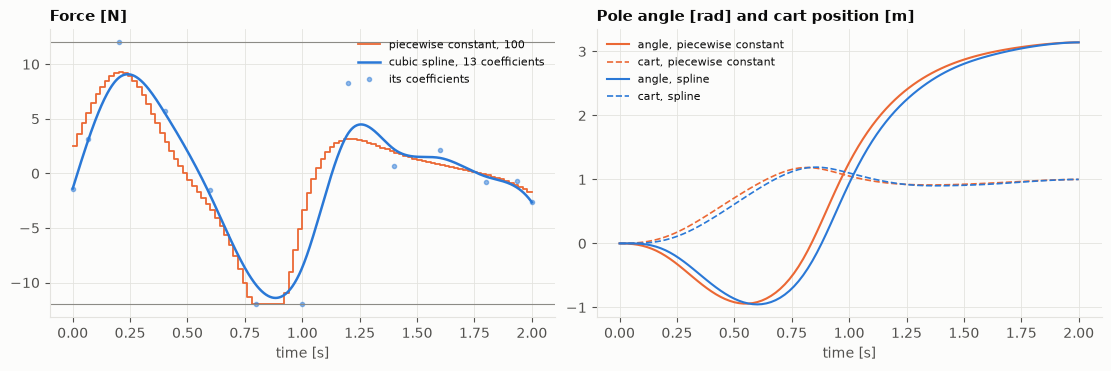

In [4]:
t_fine = np.linspace(0.0, T_END, 801)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.step(np.arange(STEPS + 1) * H, np.append(steps_u, steps_u[-1]), where="post", color=plotstyle.ORANGE, lw=1.3, label=f"piecewise constant, {STEPS}")
ax1.plot(t_fine, force(t_fine), color=plotstyle.BLUE, lw=1.8, label=f"cubic spline, {N_FORCE} coefficients")
greville = np.array([FORCE_KNOTS[i + 1 : i + 4].mean() for i in range(N_FORCE)])  # where each coefficient acts most
ax1.plot(greville, spline_c, "o", color=plotstyle.BLUE, ms=3, alpha=0.5, label="its coefficients")
ax1.axhline(U_MAX, color=plotstyle.NEUTRAL, lw=0.8)
ax1.axhline(-U_MAX, color=plotstyle.NEUTRAL, lw=0.8)
ax1.set_xlabel("time [s]")
ax1.set_title("Force [N]")
ax1.legend(fontsize=8)
t_nodes = np.arange(STEPS + 1) * H
for label, color in (("piecewise constant", plotstyle.ORANGE), ("spline", plotstyle.BLUE)):
  ax2.plot(t_nodes, results[label]["X"][:, 1], color=color, lw=1.5, label=f"angle, {label}")
  ax2.plot(t_nodes, results[label]["X"][:, 0], "--", color=color, lw=1.2, label=f"cart, {label}")
ax2.set_xlabel("time [s]")
ax2.set_title("Pole angle [rad] and cart position [m]")
ax2.legend(fontsize=8)
plt.show()

Both swing the pole up, with 17 % fewer variables for the spline, which is not a faster solve:
each coefficient reaches into 40 intervals, which fills the KKT matrix. The spline's cost is
2.9 % higher. With 13 coefficients it cannot turn as sharply, and its force stays inside the
bound by 0.6 N where its coefficients touch it, since the convex hull is a sufficient condition.
In return the force is smooth, an actuator can follow it, and it is bounded between samples.
That is also the time grid's own guarantee: replayed by an adaptive integrator (tolerance
$10^{-11}$), each force brings the system to the goal within $10^{-3}$, the transcription's RK4
error.

`at()` agrees with SciPy's `BSpline.design_matrix` to $4 \times 10^{-15}$, and its Jacobian in
the coefficients has at most four entries per time, the cubic's local support.

## A path around obstacles, as a quadratic program

A point with double-integrator dynamics moves from $(0, 0)$ to $(10, 0)$ in 10 s, starting and
ending at rest, past two circular obstacles. It minimizes $\int \|\ddot p\|^2 dt$, with each
velocity component within 2 m/s and each acceleration component within 1 m/s². The position is a
cubic spline of 20 pieces, 23 coefficients per axis, and everything is linear in them:

- velocity and acceleration are splines whose coefficients are $D_1 c$ and $D_2 c$
  (`derivative()` computes them). Bounding those coefficients bounds the curves;
- each cubic piece is a Bézier curve whose four control points are a linear map of $c$. The
  piece lies in their convex hull, so if all four lie in a half-plane away from an obstacle,
  the whole piece does;
- the half-planes come from a rough guess that says which side to pass on: above the first
  obstacle, below the second. Each piece gets, for each obstacle, the half-plane facing its
  guessed position, touching the circle.

The objective is $c^\top G_2 c$, with $G_2$ the Gram matrix of the second derivatives. The
problem is a QP, and `sc.solver(..., "piqp")` proves it so and solves it.

In [5]:
T_PATH, PIECES = 10.0, 20
PATH_KNOTS = clamped(0.0, T_PATH, PIECES)
N_PATH = PATH_KNOTS.size - 4
V_MAX, A_MAX = 2.0, 1.0
P_START, P_GOAL = np.array([0.0, 0.0]), np.array([10.0, 0.0])
OBSTACLES = [(np.array([3.0, 0.2]), 1.0), (np.array([7.0, -0.3]), 1.0)]

unit = [interp.BSpline(PATH_KNOTS, np.eye(N_PATH)[i], 3) for i in range(N_PATH)]
D1 = np.column_stack([np.asarray(b.derivative().coeffs) for b in unit])  # velocity's coefficients from the path's
D2 = np.column_stack([np.asarray(b.derivative(2).coeffs) for b in unit])  # acceleration's
breaks = np.unique(PATH_KNOTS)
bernstein = np.array([[1, 0, 0, 0], [8, 12, 6, 1], [1, 6, 12, 8], [0, 0, 0, 1]]) / np.array([[1], [27], [27], [1]])  # at s = 0, 1/3, 2/3, 1
to_bezier = []  # per piece: its 4 Bezier control points from the path's coefficients
for a, b in zip(breaks[:-1], breaks[1:], strict=True):
  at_points = SciBSpline.design_matrix(a + (b - a) * np.array([0.0, 1 / 3, 2 / 3, 1 - 1e-12]), PATH_KNOTS, 3).toarray()
  to_bezier.append(np.linalg.solve(bernstein, at_points))
guess_path = np.column_stack([np.linspace(0.0, 10.0, N_PATH), 1.6 * np.sin(2 * np.pi * np.linspace(0.0, 1.0, N_PATH))])  # above the first, below the second
halfplanes = []  # per piece and obstacle: the normal and offset of the half-plane its control points must keep to
for B in to_bezier:
  middle = (B @ guess_path).mean(axis=0)
  for centre, radius in OBSTACLES:
    normal = (middle - centre) / np.linalg.norm(middle - centre)
    halfplanes.append((B, normal, normal @ centre + radius))


@sc.problem(vars=sc.L("P", (N_PATH, 2)))
def path_qp(P):
  ends = SciBSpline.design_matrix(np.array([0.0, T_PATH]), PATH_KNOTS, 3).toarray()
  velocity, acceleration = sc.const(D1) @ P, sc.const(D2) @ P
  keep_out = sc.concat([sc.const(B) @ P @ sc.const(normal) - offset for B, normal, offset in halfplanes])
  return sc.ProblemSpec(
    minimize=(P * (sc.const(gram(PATH_KNOTS, 3, nu=2)) @ P)).sum(),  # the integral of |acceleration|^2
    eq=((sc.const(ends) @ P - np.array([P_START, P_GOAL])).reshape((4,)), velocity[0], velocity[-1]),
    ineq=(sc.bounded(velocity.reshape((velocity.size,)), -V_MAX, V_MAX), sc.bounded(acceleration.reshape((acceleration.size,)), -A_MAX, A_MAX), sc.bounded(keep_out, lo=0.0)),
  )


plan = sc.solver(path_qp, "piqp")
n_eq_path = 8
n_ineq_path = 2 * D1.shape[0] * 2 // 2 + 2 * D2.shape[0] * 2 // 2 + len(halfplanes) * 4
P, *_ = plan(np.zeros((N_PATH, 2)), np.zeros((N_PATH, 2)), np.zeros(n_eq_path), np.zeros(n_ineq_path), ())
plan_stats = plan.solver_stats()
path = SciBSpline(PATH_KNOTS, P, 3)
t_dense = np.linspace(0.0, T_PATH, 20_001)
xy = path(t_dense)
clearance = min(float((np.linalg.norm(xy - centre, axis=1) - radius).min()) for centre, radius in OBSTACLES)
speed_max = float(np.abs(path.derivative()(t_dense)).max())
accel_max = float(np.abs(path.derivative(2)(t_dense)).max())
print(f"PIQP: {plan_stats.to_solver_status().name}, {plan_stats.iter} iterations, {1e3 * plan_stats.t_total:.2f} ms; {N_PATH * 2} variables, {n_ineq_path} inequalities")
print(f"clearance from the obstacles at 20 001 times: {clearance:.3f} m; |velocity| per axis <= {speed_max:.3f} (limit {V_MAX}); |acceleration| <= {accel_max:.3f} (limit {A_MAX})")
print(f"integral of |acceleration|^2: {plan_stats.obj:.4f}")

PIQP: OK, 13 iterations, 0.85 ms; 46 variables, 246 inequalities
clearance from the obstacles at 20 001 times: 0.091 m; |velocity| per axis <= 1.318 (limit 2.0); |acceleration| <= 1.000 (limit 1.0)
integral of |acceleration|^2: 5.0784


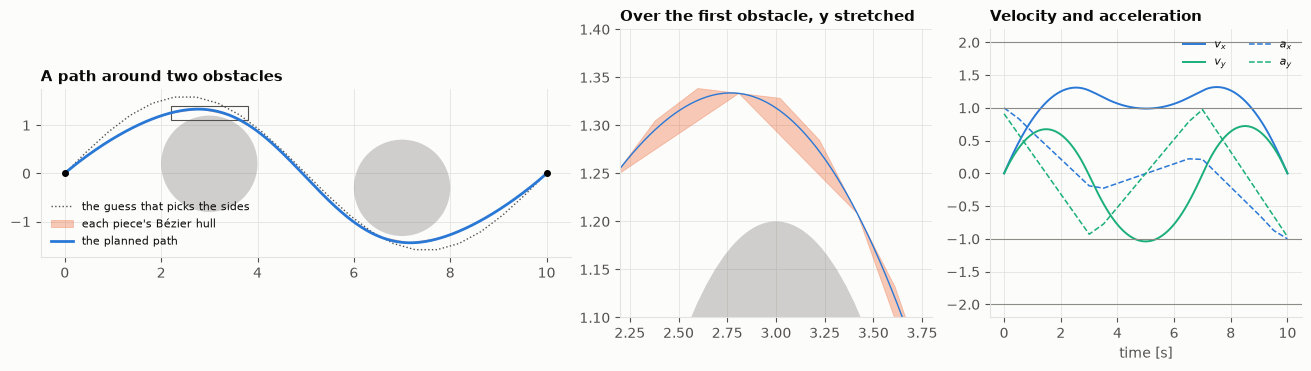

In [6]:
fig, (ax1, zoom, ax2) = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.7, 1, 1]})
for centre, radius in OBSTACLES:
  ax1.add_patch(Circle(centre, radius, color=plotstyle.NEUTRAL, alpha=0.4, lw=0))
ax1.plot(guess_path[:, 0], guess_path[:, 1], ":", color=plotstyle.TEXT_SECONDARY, lw=1, label="the guess that picks the sides")
for i, B in enumerate(to_bezier):
  control = B @ P
  hull = control[ConvexHull(control).vertices]
  ax1.fill(*hull.T, color=plotstyle.ORANGE, alpha=0.35, lw=0.6, ec=plotstyle.ORANGE, label="each piece's Bézier hull" if i == 0 else None)
ax1.plot(xy[:, 0], xy[:, 1], color=plotstyle.BLUE, lw=2, label="the planned path")
ax1.plot(*np.array([P_START, P_GOAL]).T, "ko", ms=4)
ax1.set_aspect("equal")
ax1.set_title("A path around two obstacles")
ax1.legend(fontsize=8, loc="lower left")
zoom.set(xlim=(2.2, 3.8), ylim=(1.1, 1.4), title="Over the first obstacle, y stretched")
zoom.add_patch(Circle(OBSTACLES[0][0], OBSTACLES[0][1], color=plotstyle.NEUTRAL, alpha=0.4, lw=0))
for B in to_bezier:
  control = B @ P
  zoom.fill(*control[ConvexHull(control).vertices].T, color=plotstyle.ORANGE, alpha=0.35, lw=0.6, ec=plotstyle.ORANGE)
zoom.plot(xy[:, 0], xy[:, 1], color=plotstyle.BLUE, lw=1)
ax1.add_patch(Rectangle((2.2, 1.1), 1.6, 0.3, fill=False, ec=plotstyle.TEXT_SECONDARY, lw=0.8))
ax2.plot(t_dense, path.derivative()(t_dense)[:, 0], color=plotstyle.BLUE, lw=1.4, label="$v_x$")
ax2.plot(t_dense, path.derivative()(t_dense)[:, 1], color=plotstyle.AQUA, lw=1.4, label="$v_y$")
ax2.plot(t_dense, path.derivative(2)(t_dense)[:, 0], "--", color=plotstyle.BLUE, lw=1.1, label="$a_x$")
ax2.plot(t_dense, path.derivative(2)(t_dense)[:, 1], "--", color=plotstyle.AQUA, lw=1.1, label="$a_y$")
for bound in (V_MAX, -V_MAX, A_MAX, -A_MAX):
  ax2.axhline(bound, color=plotstyle.NEUTRAL, lw=0.8)
ax2.set_xlabel("time [s]")
ax2.set_title("Velocity and acceleration")
ax2.legend(fontsize=8, ncol=2)
plt.show()

PIQP solves the 46-variable QP with its 246 inequalities in 13 iterations, about a millisecond.
Checked at 20 001 times, the path stays at least 9 cm clear of both obstacles: the half-planes
are conservative: the pieces' hulls (orange, magnified in the middle panel) press against them,
and the path keeps a margin inside its hulls. The acceleration rides its bound on the way round. The velocity stays within
1.32 m/s, its bound inactive. Every constraint is guaranteed between samples, not only at them, because each is a
condition on control points.

## The generated C

The swing-up's force profile as a C function of its coefficients and a time: the value and its
time derivative, for a controller that plays the plan back.

In [7]:
@sc.function(sc.L("c", N_FORCE), sc.L("t", ()), output=sc.G("u", "du_dt"), name="force_profile")
def force_profile(c, t):
  u = interp.BSpline(FORCE_KNOTS, c, 3)(t)
  return u, sc.gradient(u, t)


module = write_module(force_profile, GENERATED)
u_now, du_now = force_profile(spline_c, 0.73)
print(f"{module.source_name}: {len(module.source.splitlines())} lines; u(0.73 s) = {float(u_now):.4f} N, du/dt = {float(du_now):.2f} N/s (SciPy: {force(0.73):.4f}, {force.derivative()(0.73):.2f})")

force_profile.c: 114 lines; u(0.73 s) = -7.8742 N, du/dt = -40.36 N/s (SciPy: -7.8742, -40.36)


The files are in `examples/generated/interp/spline_trajectories/`.

## Checks

In [8]:
assert all(r["status"].ok for r in results.values()) and results["spline"]["vars"] < results["piecewise constant"]["vars"]
assert at_error < 1e-13 and len(force_pattern.rows) <= 4 * HALF_STEPS.size
assert np.abs(end_spline - GOAL).max() < 5e-3 and np.abs(end_steps - GOAL).max() < 5e-3
assert np.abs(force(t_fine)).max() <= U_MAX + 1e-9
assert plan_stats.to_solver_status().ok and clearance >= -1e-9
assert speed_max <= V_MAX + 1e-9 and accel_max <= A_MAX + 1e-9
assert abs(float(u_now) - force(0.73)) < 1e-12 and abs(float(du_now) - force.derivative()(0.73)) < 1e-10
print("all 7 checks passed")

all 7 checks passed
